# Max value and data columns check

In [1]:
import os
import pandas as pd
from my_helpers import *

In [2]:
%load_ext autoreload
%autoreload 2

In [4]:
folder_path = '../data'  
max_values = []  
min_values = []  
separators = ' '
corrupted_files = ['../data/DATA2803/6ALEXANDRA/ALEXANDRA_5_DT_100_rawdata.csv','../data/DATA2803/6ALEXANDRA/ALEXANDRA_4_DQ_100_rawdata.csv','../data/DATA2903/7Jules']
sniffer = csv.Sniffer()
cap_text_cols = ['TimeStamps', 'MergeTimeStamps', 'ScanSizeX', 'ScanSizeY']
cap_numeric_cols =  list(map(str,range(3024)))
cap_cols = cap_text_cols + cap_numeric_cols
processed_cap_cols = cap_text_cols + ['cap_img','trial','gesture','subject','day']
wrist_cols = ['wrist_x','wrist_y','wrist_z']
finger_cols = sum([[f'{x}_{y}_x', f'{x}_{y}_y', f'{x}_{y}_z'] for x in ['Thumb','Index','Middle','Ring','Pinky'] for y in range(5)],[]) 
last_fingers_cols = [x for x in finger_cols if '_4_' in x]
day_cols = ['Timestamp','skeleton',	'ScanSizeX','ScanSizeY','trial'	,'gesture','subject','day','cap_img']

skel_cols = ['Timestamp'] + wrist_cols + finger_cols

subject = 0
no_cap=0
day = 0
ignored=0
trunc=True

# Loop through each day data folder
for folder in os.listdir(folder_path):

    if not folder.startswith('DATA'):  
        continue

    path = os.path.join(folder_path, folder)
    day_data = pd.DataFrame(columns=day_cols)

    # Loop through each kid data folder
    for kid in os.listdir(path):

        kid_folder = os.path.join(path, kid)

        if(kid_folder) in corrupted_files:
            continue

        skeleton_file = [f for f in os.listdir(kid_folder) if f.endswith('handleap.csv')]

        if len(skeleton_file) != 1:
            #1 occurence of this error
            raise ValueError('Found more than one skeleton file')
        
        skeleton_path = os.path.join(kid_folder, skeleton_file[0])
        print(skeleton_path)
        kid_skeleton = read_skeleton(skeleton_path,sniffer,skel_cols)
        kid_skeleton = process_skeleton(kid_skeleton,last_fingers_cols,trunc=trunc)
        kid_cap = pd.DataFrame(columns=processed_cap_cols).rename(columns={'TimeStamps': 'Timestamp'})

        # Loop through each gesture data, process and concatenate
        for filename in os.listdir(kid_folder):
            if filename.endswith('rawdata.csv'):  # Check only files that end with'rawdata.csv'r
                file_path = os.path.join(kid_folder, filename)
                
                if (file_path in corrupted_files) :
                    continue

                print(file_path)

                cap_img = read_cap_img(file_path,sniffer,cap_cols)
                
                #check for max and min values of capactive images pixels
                max_value = cap_img[cap_numeric_cols].values.max()
                min_value = cap_img[cap_numeric_cols].values.min()
                max_values.append(max_value)
                min_values.append(min_value)

                cap_img = process_cap_img(cap_img,trunc=trunc)
                
                f = filename.split('_')
                trial , gesture = f[1], f[2]

                #add folders informatiom to data
                cap_img['trial'] = trial
                cap_img['gesture'] = gesture
                cap_img['subject'] = subject
                cap_img['day'] = day

                
                
                kid_cap = pd.concat([kid_cap,cap_img],ignore_index=True)
        #ŦO DO : add skeleton data to kid_cap
        #merge(kid_cap,skeleton_data)
        #add result to day data
        if kid_cap.empty:
            no_cap+=1
            continue
        kid_data = map_cap_img_to_skeleton(kid_skeleton,kid_cap)
        if(kid_data.empty):
            ignored+=1
        display(kid_data)
        subject+=1 
    day+=1  
    day_data = pd.concat([day_data,kid_data],ignore_index=True)    
    day_data.to_pickle(f'../data/processed/day{day}.pkl')

../data/DATA3003/16Yaman/useryaman_2023-03-30_11-35-18_1644_handleap.csv
../data/DATA3003/16Yaman/YAMAN_3_DQ_100_rawdata.csv
../data/DATA3003/16Yaman/YAMAN_4_LQ_100_rawdata.csv
../data/DATA3003/16Yaman/YAMAN_1_UP_100_rawdata.csv
../data/DATA3003/16Yaman/YAMAN_5_LT_100_rawdata.csv
../data/DATA3003/16Yaman/YAMAN_2_DT_100_rawdata.csv
../data/DATA3003/16Yaman/YAMAN_6_UP_100_rawdata.csv


,Timestamp,skeleton,ScanSizeX,ScanSizeY,trial,gesture,subject,day,cap_img
0,1.680168e+12,"[[-244, 272, 257], [-220, 253, 240], [-220, 25...",72,41,3,DQ,0,0,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,..."
1,1.680168e+12,"[[-245, 271, 257], [-220, 253, 240], [-220, 25...",72,41,3,DQ,0,0,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,..."
2,1.680168e+12,"[[-246, 271, 257], [-222, 253, 240], [-222, 25...",72,41,3,DQ,0,0,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,..."
3,1.680168e+12,"[[-247, 270, 257], [-222, 252, 240], [-222, 25...",72,41,3,DQ,0,0,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,..."
4,1.680168e+12,"[[-247, 270, 256], [-223, 252, 239], [-223, 25...",72,41,3,DQ,0,0,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,..."
...,...,...,...,...,...,...,...,...,...
370,1.680169e+12,"[[-264, 289, 332], [-248, 275, 308], [-248, 27...",72,41,5,LT,0,0,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,..."
371,1.680169e+12,"[[-264, 288, 333], [-248, 274, 309], [-248, 27...",72,41,5,LT,0,0,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,..."
372,1.680169e+12,"[[-266, 284, 336], [-251, 270, 310], [-251, 27...",72,41,5,LT,0,0,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,..."
373,1.680169e+12,"[[-268, 283, 338], [-254, 268, 312], [-254, 26...",72,41,5,LT,0,0,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,..."


../data/DATA3003/15Clemence/userclemence_2023-03-30_11-05-54_8874_handleap.csv
../data/DATA3003/15Clemence/CLEMENCE_4_LT_100_rawdata.csv


""


../data/DATA3003/21AnnaSofia/useranna_sophia_2023-03-30_15-25-42_10472_handleap.csv
../data/DATA3003/21AnnaSofia/ANNA SOFIA_4_DQ_100_rawdata.csv
../data/DATA3003/21AnnaSofia/ANNA SOFIA_1_UP_100_rawdata.csv


...

,Timestamp,skeleton,ScanSizeX,ScanSizeY,trial,gesture,subject,day,cap_img
0,1.680091e+12,"[[-293, 296, 75], [-260, 287, 61], [-260, 287,...",72,41,1,UP,30,4,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,..."
1,1.680091e+12,"[[-293, 294, 77], [-260, 285, 64], [-260, 285,...",72,41,1,UP,30,4,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,..."
2,1.680091e+12,"[[-289, 292, 78], [-256, 284, 65], [-256, 284,...",72,41,1,UP,30,4,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,..."
3,1.680091e+12,"[[-285, 292, 77], [-253, 283, 64], [-253, 283,...",72,41,1,UP,30,4,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,..."
4,1.680091e+12,"[[-284, 293, 77], [-252, 283, 64], [-252, 283,...",72,41,1,UP,30,4,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,..."
...,...,...,...,...,...,...,...,...,...
1258,1.680092e+12,"[[-375, 291, 146], [-349, 284, 125], [-349, 28...",72,41,6,UP,30,4,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,..."
1259,1.680092e+12,"[[-376, 291, 146], [-351, 284, 125], [-351, 28...",72,41,6,UP,30,4,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,..."
1260,1.680092e+12,"[[-378, 292, 146], [-352, 285, 125], [-352, 28...",72,41,6,UP,30,4,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,..."
1261,1.680092e+12,"[[-379, 294, 147], [-354, 285, 125], [-354, 28...",72,41,6,UP,30,4,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,..."


../data/DATA2903/12Leonie/userleonie_2023-03-29_15-24-38_2214_handleap.csv
../data/DATA2903/12Leonie/LEONIE_4_LQ_100_rawdata.csv
../data/DATA2903/12Leonie/LEONIE_2_DT_100_rawdata.csv
../data/DATA2903/12Leonie/LEONIE_3_DQ_100_rawdata.csv
../data/DATA2903/12Leonie/LEONIE_1_UP_100_rawdata.csv
../data/DATA2903/12Leonie/LEONIE_5_LT_100_rawdata.csv
../data/DATA2903/12Leonie/LEONIE_6_UP_100_rawdata.csv


,Timestamp,skeleton,ScanSizeX,ScanSizeY,trial,gesture,subject,day,cap_img
0,1.680095e+12,"[[-197, 271, 90], [-206, 276, 61], [-206, 276,...",72,41,2,DT,31,4,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,..."
1,1.680095e+12,"[[-196, 272, 90], [-205, 276, 61], [-205, 276,...",72,41,2,DT,31,4,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,..."
2,1.680095e+12,"[[-195, 272, 90], [-205, 277, 61], [-205, 277,...",72,41,2,DT,31,4,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,..."
3,1.680095e+12,"[[-196, 273, 91], [-205, 278, 61], [-205, 278,...",72,41,2,DT,31,4,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,..."
4,1.680095e+12,"[[-197, 273, 91], [-206, 279, 62], [-206, 279,...",72,41,2,DT,31,4,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,..."
...,...,...,...,...,...,...,...,...,...
1190,1.680096e+12,"[[-225, 272, 146], [-215, 253, 119], [-215, 25...",72,41,6,UP,31,4,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,..."
1191,1.680096e+12,"[[-227, 271, 148], [-217, 250, 122], [-217, 25...",72,41,6,UP,31,4,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,..."
1192,1.680096e+12,"[[-232, 271, 149], [-220, 250, 126], [-220, 25...",72,41,6,UP,31,4,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,..."
1193,1.680096e+12,"[[-236, 272, 150], [-224, 250, 127], [-224, 25...",72,41,6,UP,31,4,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,..."


../data/DATA2903/8Miranda/usermiranda_2023-03-29_13-18-33_13423_handleap.csv
../data/DATA2903/11Tommaso/usertommaso_2023-03-29_14-51-14_8337_handleap.csv
../data/DATA2903/11Tommaso/TOMMASO_6_UP_100_rawdata.csv
../data/DATA2903/11Tommaso/TOMMASO_5_DQ_100_rawdata.csv
../data/DATA2903/11Tommaso/TOMMASO_3_DT_100_rawdata.csv
../data/DATA2903/11Tommaso/TOMMASO_2_LQ_100_rawdata.csv
../data/DATA2903/11Tommaso/TOMMASO_1_UP_100_rawdata.csv


,Timestamp,skeleton,ScanSizeX,ScanSizeY,trial,gesture,subject,day,cap_img
0,1.680093e+12,"[[-270, 288, 68], [-242, 276, 55], [-242, 276,...",72,41,1,UP,32,4,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,..."
1,1.680093e+12,"[[-270, 288, 68], [-243, 276, 54], [-243, 276,...",72,41,1,UP,32,4,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,..."
2,1.680093e+12,"[[-270, 288, 67], [-243, 276, 54], [-243, 276,...",72,41,1,UP,32,4,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,..."
3,1.680093e+12,"[[-270, 288, 67], [-243, 276, 54], [-243, 276,...",72,41,1,UP,32,4,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,..."
4,1.680093e+12,"[[-270, 288, 67], [-242, 276, 54], [-242, 276,...",72,41,1,UP,32,4,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,..."
...,...,...,...,...,...,...,...,...,...
4041,1.680093e+12,"[[-245, 253, 134], [-224, 236, 119], [-224, 23...",72,41,3,DT,32,4,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,..."
4042,1.680093e+12,"[[-244, 249, 136], [-223, 232, 120], [-223, 23...",72,41,3,DT,32,4,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,..."
4043,1.680093e+12,"[[-244, 246, 136], [-223, 230, 120], [-223, 23...",72,41,3,DT,32,4,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,..."
4044,1.680093e+12,"[[-244, 244, 136], [-224, 229, 119], [-224, 22...",72,41,3,DT,32,4,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,..."


In [6]:
ignored

9

In [5]:
no_cap

1

In [ ]:
separators

' ,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,'

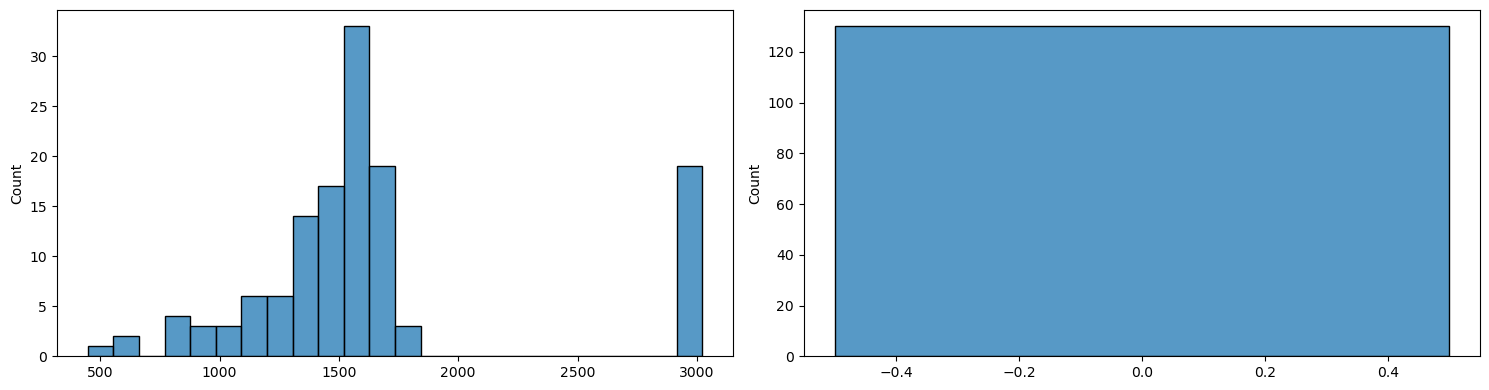

In [30]:
import seaborn as sns
import matplotlib.pyplot as plt

ax, fig = plt.subplots(1,2,figsize=(15,4))
sns.histplot(max_values, ax=fig[0])
sns.histplot(min_values, ax=fig[1])
plt.tight_layout()

In [ ]:
d = {'DT': 'Dynamic Tripod', 
     'DQ': 'Dynamic Quadrupod', 
     'LT': 'Lateral Tripod', 
     'LQ': 'Lateral Quadrupod',
     'UP': 'Native'}